In [1]:
import pandas as pd

# ===========================
# Abu Dhabi站排位赛数据
# ===========================

abu_dhabi_data = {
    'Driver': ['M VERSTAPPEN', 'L NORRIS', 'O PIASTRI', 'G RUSSELL', 'C LECLERC',
               'F ALONSO', 'G BORTOLETO', 'E OCON', 'I HADJAR', 'Y TSUNODA',
               'O BEARMAN', 'C SAINZ', 'L LAWSON', 'K ANTONELLI', 'L STROLL',
               'L HAMILTON', 'A ALBON', 'N HULKENBERG', 'P GASLY', 'F COLAPINTO'],
    
    'QualifyingPosition': list(range(1, 21)),
    'GridPosition': list(range(1, 21)),
    
    'Team': ['Red Bull Racing', 'McLaren', 'McLaren', 'Mercedes', 'Ferrari',
             'Aston Martin', 'Kick Sauber', 'Haas F1 Team', 'Racing Bulls', 'Red Bull Racing',
             'Haas F1 Team', 'Williams', 'Racing Bulls', 'Mercedes', 'Aston Martin',
             'Ferrari', 'Williams', 'Kick Sauber', 'Alpine', 'Alpine'],
    
    'TrackType': ['high_speed'] * 20,
    'GlobalRound': [1] * 20,
}

abu_dhabi_df = pd.DataFrame(abu_dhabi_data)

# ===========================
# 补齐特征
# ===========================

# 加载映射数据
teams_info = pd.read_csv('data/teams_info.csv')
driver_features = pd.read_csv('data/driver_features.csv')
race_data = pd.read_csv('data/f1_race_data_cleaned.csv')

team_tier_map = dict(zip(teams_info['Team'], teams_info['Tier']))
driver_recent5_map = dict(zip(driver_features['Driver'], driver_features['Recent5Avg']))
driver_dnf_map = dict(zip(driver_features['Driver'], driver_features['DNFRate']))

unique_drivers = race_data['Driver'].unique()
driver_to_idx = {driver: idx for idx, driver in enumerate(unique_drivers)}

track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}

abu_dhabi_df['TrackTypeIdx'] = abu_dhabi_df['TrackType'].map(track_type_map)
abu_dhabi_df['TierCode'] = abu_dhabi_df['Team'].map(team_tier_map)
abu_dhabi_df['DriverIdx'] = abu_dhabi_df['Driver'].map(driver_to_idx)
abu_dhabi_df['Recent5Avg'] = abu_dhabi_df['Driver'].map(driver_recent5_map)
abu_dhabi_df['CumDNFRate'] = abu_dhabi_df['Driver'].map(driver_dnf_map)

abu_dhabi_df.to_csv('./data/abu_dhabi_ready.csv', index=False)

print("Abu Dhabi qualify data save to ./data/abu_dhabi_ready.csv")
print(abu_dhabi_df[['Driver', 'Team', 'GridPosition', 'TierCode']])

Abu Dhabi qualify data save to ./data/abu_dhabi_ready.csv
          Driver             Team  GridPosition  TierCode
0   M VERSTAPPEN  Red Bull Racing             1         0
1       L NORRIS          McLaren             2         0
2      O PIASTRI          McLaren             3         0
3      G RUSSELL         Mercedes             4         0
4      C LECLERC          Ferrari             5         1
5       F ALONSO     Aston Martin             6         2
6    G BORTOLETO      Kick Sauber             7         2
7         E OCON     Haas F1 Team             8         2
8       I HADJAR     Racing Bulls             9         2
9      Y TSUNODA  Red Bull Racing            10         0
10     O BEARMAN     Haas F1 Team            11         2
11       C SAINZ         Williams            12         1
12      L LAWSON     Racing Bulls            13         2
13   K ANTONELLI         Mercedes            14         0
14      L STROLL     Aston Martin            15         2
15    L HAMILT

In [10]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# 只改这一行：换成 Abu Dhabi 数据
abu_dhabi_df = pd.read_csv('data/abu_dhabi_ready.csv')
trace = az.from_netcdf('model/f1_trace.nc')

# 提取后验参数
posterior = trace.posterior
n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]

alpha = posterior['alpha'].values.flatten()
beta_team = posterior['beta_team'].values.reshape(-1, 3)
gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
eta_grid = posterior['eta_grid'].values.flatten()
delta_track = posterior['delta_track'].values.reshape(-1, 3)
epsilon_trend = posterior['epsilon_trend'].values.flatten()
zeta_dnf = posterior['zeta_dnf'].values.flatten()
sigma_race = posterior['sigma_race'].values.flatten()

n_samples = len(alpha)
n_simulations = 500000

print(f"Starting Monte Carlo simulation ({n_simulations:,} iterations)...")

# ===========================
# 蒙特卡洛模拟：生成完整排名
# ===========================

position_counts = np.zeros((len(abu_dhabi_df), 20))

for sim in range(n_simulations):
    if sim % 10000 == 0:
        print(f"  Progress: {sim/n_simulations*100:.1f}%", end='\r')
    
    sample_idx = np.random.randint(0, n_samples)
    
    predicted_positions = []
    for idx, row in abu_dhabi_df.iterrows():
        mu = (
            alpha[sample_idx] +
            beta_team[sample_idx, int(row['TierCode'])] +
            gamma_driver[sample_idx, int(row['DriverIdx'])] +
            eta_grid[sample_idx] * row['GridPosition'] +
            delta_track[sample_idx, int(row['TrackTypeIdx'])] +
            epsilon_trend[sample_idx] * row['Recent5Avg'] +
            zeta_dnf[sample_idx] * row['CumDNFRate']
        )
        
        pos = np.random.normal(mu, sigma_race[sample_idx])
        predicted_positions.append(pos)
    
    # 关键：使用argsort得到排名，确保1-20不重复
    ranks = np.argsort(predicted_positions) + 1
    
    for driver_idx, rank in enumerate(ranks):
        if 1 <= rank <= 20:
            position_counts[driver_idx, rank - 1] += 1

print(f"  Progress: 100.0% - Complete!")

position_probs = position_counts / n_simulations

# ===========================
# 计算统计量
# ===========================

results = []
for idx, row in abu_dhabi_df.iterrows():
    probs = position_probs[idx]
    
    # 期望值（Mean）
    expected_pos = np.sum([(i+1) * probs[i] for i in range(20)])
    
    # 中位数（Median）
    cumsum = np.cumsum(probs)
    median_pos = np.searchsorted(cumsum, 0.5) + 1
    
    # 众数（Mode）- 概率最高的排名
    mode_pos = np.argmax(probs) + 1
    
    # 分位数
    q25 = np.searchsorted(cumsum, 0.25) + 1
    q75 = np.searchsorted(cumsum, 0.75) + 1
    ci_lower = np.searchsorted(cumsum, 0.025) + 1
    ci_upper = np.searchsorted(cumsum, 0.975) + 1
    
    # 🔥 新增：Top3/5/10概率和熵
    p_top3 = probs[:3].sum()
    p_top5 = probs[:5].sum()
    p_top10 = probs[:10].sum()
    entropy = -np.sum(probs[probs > 0] * np.log(probs[probs > 0] + 1e-10))
    
    results.append({
        'Driver': row['Driver'],
        'Mean': expected_pos,
        'Median': median_pos,
        'Mode': mode_pos,
        'P_Win': probs[0],
        'P_Top3': p_top3,
        'P_Top5': p_top5,
        'P_Top10': p_top10,
        'P_Podium': probs[:3].sum(),
        'P_Points': probs[:10].sum(),
        'Q25': q25,
        'Q75': q75,
        'CI_2.5': ci_lower,
        'CI_97.5': ci_upper,
        'Entropy': entropy
    })

# ===========================
# 🔥 关键修复：排序并生成唯一的 PredictedRank
# ===========================

results_df = pd.DataFrame(results)

# 按照你的排序规则排序
results_df = results_df.sort_values(
    by=['Mode', 'Mean', 'P_Win', 'Q25', 'CI_2.5'],
    ascending=[True, True, False, True, True]
)

# 🎯 关键：根据排序后的顺序，累加生成唯一的排名（1-20）
results_df.insert(0, 'PredictedRank', range(1, len(results_df) + 1))

# 重新排列列
results_df = results_df[[
    'PredictedRank',
    'Driver', 
    'Mean',
    'Median',
    'Mode',
    'P_Win',
    'P_Top3',
    'P_Top5',
    'P_Top10',
    'P_Podium',
    'P_Points',
    'Q25',
    'Q75',
    'CI_2.5',
    'CI_97.5',
    'Entropy'
]]

# ===========================
# 输出结果
# ===========================

print("\n" + "=" * 100)
print("Abu Dhabi GP Prediction (With Ranking Constraints)")
print("=" * 100)
print("\nSorting Rule: Mode → Mean → P_Win(desc) → Q25 → CI_2.5")
print("PredictedRank = Unique ranking (1-20) based on sorting rules\n")

print(results_df[['PredictedRank', 'Driver', 'Mean', 'Mode', 
                  'P_Win', 'P_Top3', 'P_Top10']].to_string(index=False))

# 保存
results_df.to_csv('./result/abu_dhabi_predict_menka.csv', index=False)

print("\n" + "=" * 100)
print("✅ Prediction results saved to abu_dhabi_predict_menka.csv")
print("   'PredictedRank' column = Final unique ranking (1-20)")
print("=" * 100)

# ===========================
# 验证：确保没有重复排名
# ===========================

print("\n" + "=" * 100)
print("Validation Results")
print("=" * 100)

# 检查 PredictedRank 是否唯一
assert results_df['PredictedRank'].nunique() == 20, "❌ PredictedRank has duplicates!"
assert set(results_df['PredictedRank']) == set(range(1, 21)), "❌ PredictedRank incomplete!"

print("✅ PredictedRank: 1-20, no duplicates, complete")

# 检查 Mode 可能的重复情况
mode_duplicates = results_df['Mode'].value_counts()
if (mode_duplicates > 1).any():
    print(f"\n⚠️  Mode has duplicate values (this is normal):")
    print(mode_duplicates[mode_duplicates > 1])
    print("   → This is why we need Mean, P_Win, etc. as tie-breakers")

# 展示前5名的详细排序逻辑
print("\nTop 5 Sorting Logic:")
top5 = results_df.head(5)
for _, row in top5.iterrows():
    print(f"P{row['PredictedRank']:.0f} {row['Driver']:18s}  "
          f"Mode={row['Mode']:2.0f}  Mean={row['Mean']:5.2f}  "
          f"P_Win={row['P_Win']:5.1%}  Q25={row['Q25']:2.0f}  "
          f"Entropy={row['Entropy']:.3f}")

print("\n" + "=" * 100)

Starting Monte Carlo simulation (500,000 iterations)...
  Progress: 100.0% - Complete!

Abu Dhabi GP Prediction (With Ranking Constraints)

Sorting Rule: Mode → Mean → P_Win(desc) → Q25 → CI_2.5
PredictedRank = Unique ranking (1-20) based on sorting rules

 PredictedRank       Driver      Mean  Mode    P_Win   P_Top3  P_Top10
             1 M VERSTAPPEN  3.417200     1 0.239902 0.634022 0.961938
             2     L NORRIS  4.332834     1 0.186250 0.532426 0.918906
             3    O PIASTRI  5.288408     2 0.145638 0.435910 0.867778
             4    G RUSSELL  6.282590     3 0.112146 0.347050 0.809720
             5    C LECLERC  7.288670     5 0.083504 0.266594 0.746354
             6     F ALONSO  8.207728     5 0.062146 0.201318 0.682140
             7     I HADJAR 10.290442     6 0.025336 0.086366 0.525236
             8    Y TSUNODA 10.824124     7 0.018734 0.065098 0.483600
             9      C SAINZ 11.784004     9 0.010220 0.036354 0.405762
            10  G BORTOLETO  9.00


✅ Complete


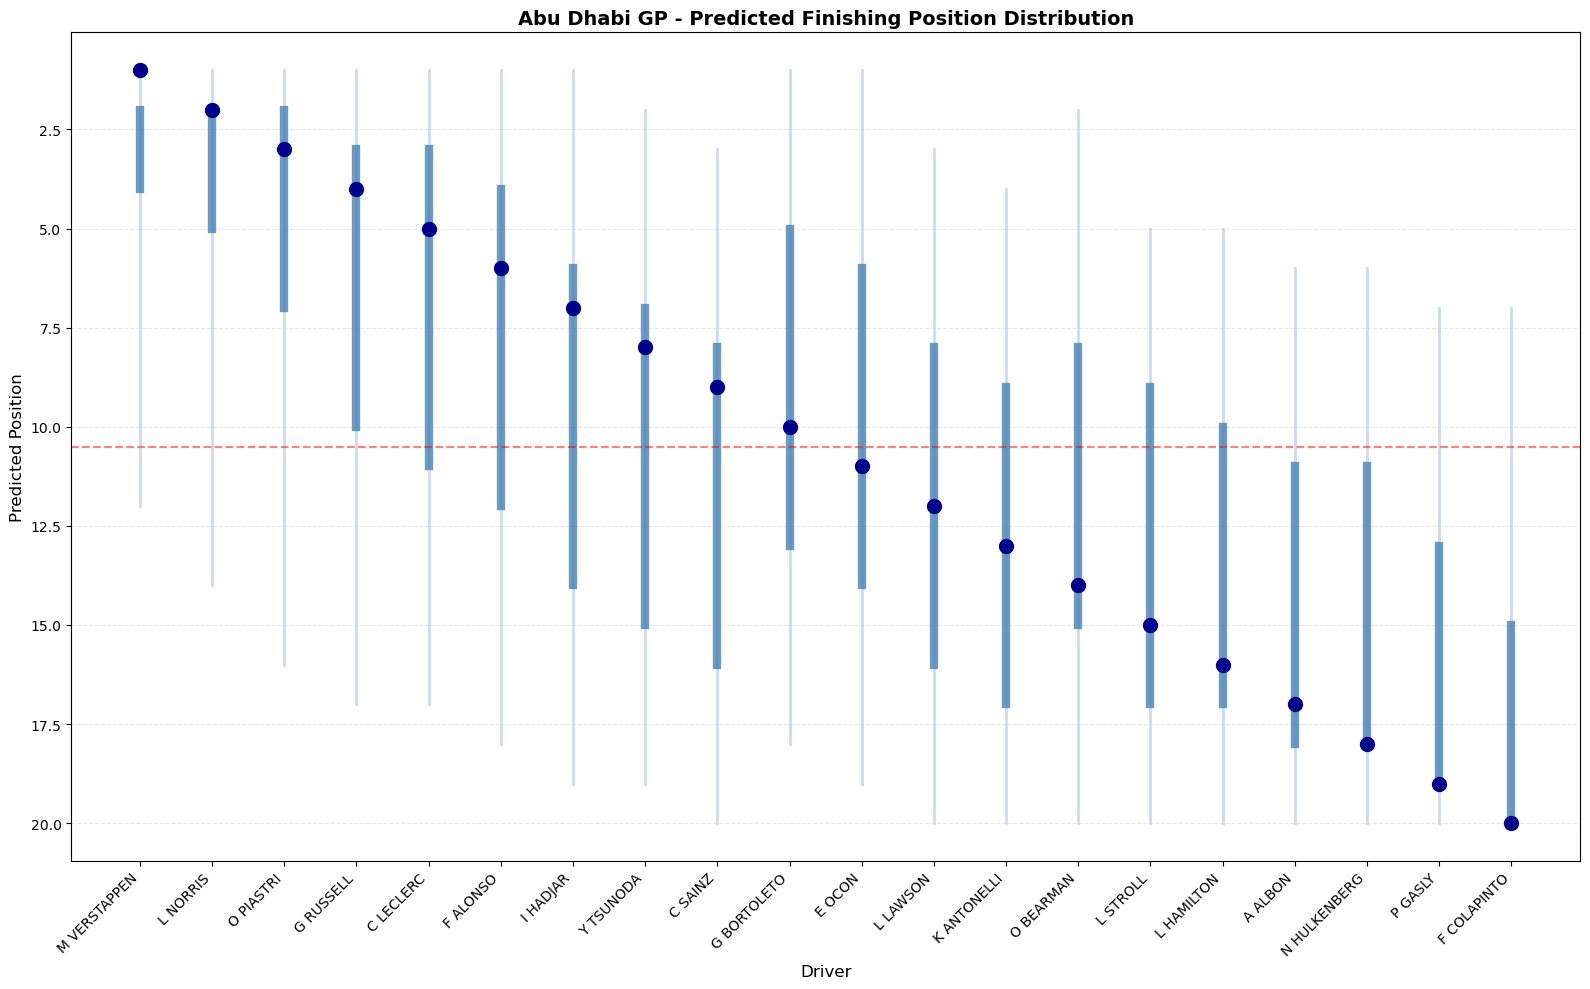

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# 绘图
# ===========================

results_df = pd.read_csv('./result/abu_dhabi_predict_menka.csv')

fig, ax = plt.subplots(figsize=(16, 10))

drivers = results_df['Driver'].values
predicted_rank = results_df['PredictedRank'].values
q25 = results_df['Q25'].values
q75 = results_df['Q75'].values
ci_lower = results_df['CI_2.5'].values
ci_upper = results_df['CI_97.5'].values

x_pos = np.arange(len(drivers))

# 绘制置信区间和分位数
for i in range(len(drivers)):
    ax.plot([x_pos[i], x_pos[i]], [ci_lower[i], ci_upper[i]], 
            color='lightsteelblue', linewidth=2, alpha=0.6)
    ax.plot([x_pos[i], x_pos[i]], [q25[i], q75[i]], 
            color='steelblue', linewidth=6, alpha=0.8)

# 绘制预测排名点
ax.scatter(x_pos, predicted_rank, color='darkblue', s=100, zorder=3)

# 设置坐标轴
ax.set_xticks(x_pos)
ax.set_xticklabels(drivers, rotation=45, ha='right')
ax.set_xlabel('Driver', fontsize=12)
ax.set_ylabel('Predicted Position', fontsize=12)
ax.set_title('Abu Dhabi GP - Predicted Finishing Position Distribution', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=10.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.savefig('assets/abu_dhabi_position_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Complete")
plt.show()

In [8]:
import pandas as pd

# Load prediction results
prediction = pd.read_csv('./result/abu_dhabi_predict_menka.csv')

# Current standings (from images)
current_standings = {
    'L NORRIS': 408,
    'M VERSTAPPEN': 396,
    'O PIASTRI': 392,
    'G RUSSELL': 309,
    'C LECLERC': 230,
    'L HAMILTON': 152,
    'K ANTONELLI': 150,
    'A ALBON': 73,
    'C SAINZ': 64,
    'I HADJAR': 51,
    'N HULKENBERG': 49,
    'F ALONSO': 48,
    'O BEARMAN': 41,
    'L LAWSON': 38,
    'Y TSUNODA': 33,
    'E OCON': 32,
    'L STROLL': 32,
    'P GASLY': 22,
    'G BORTOLETO': 19,
    'F COLAPINTO': 0,
    'J DOOHAN': 0  # Jack Doohan did not participate in Abu Dhabi
}

# F1 points system (top 10 positions)
points_system = {
    1: 25,
    2: 18,
    3: 15,
    4: 12,
    5: 10,
    6: 8,
    7: 6,
    8: 4,
    9: 2,
    10: 1
}

# Calculate Abu Dhabi predicted points
prediction['Abu_Dhabi_Points'] = prediction['PredictedRank'].map(
    lambda x: points_system.get(x, 0)
)

# Add current points
prediction['Current_Points'] = prediction['Driver'].map(current_standings)

# Calculate final total points
prediction['Final_2025_Points'] = (
    prediction['Current_Points'] + prediction['Abu_Dhabi_Points']
)

# Sort by final total points
final_standings = prediction[[
    'Driver', 
    'PredictedRank', 
    'Abu_Dhabi_Points',
    'Current_Points', 
    'Final_2025_Points'
]].sort_values('Final_2025_Points', ascending=False)

# Add final championship rank
final_standings.insert(0, 'Final_Championship_Rank', range(1, len(final_standings) + 1))

print("\n" + "=" * 100)
print("2025 Season Final Championship Standings Prediction (Including Abu Dhabi GP)")
print("=" * 100)
print(final_standings.to_string(index=False))

# Save results
final_standings.to_csv('./result/final_2025_championship_prediction.csv', index=False)

print("\n" + "=" * 100)
print("✅ Final championship standings saved to final_2025_championship_prediction.csv")
print("=" * 100)

# Display top 3 detailed information
print("\n🏆 2025 Drivers' Championship Predicted Top 3:")
for idx, row in final_standings.head(3).iterrows():
    print(f"\nP{row['Final_Championship_Rank']:.0f} - {row['Driver']}")
    print(f"   Current Points: {row['Current_Points']:.0f}")
    print(f"   Abu Dhabi Predicted Position: P{row['PredictedRank']:.0f} (+{row['Abu_Dhabi_Points']:.0f} pts)")
    print(f"   Final Total Points: {row['Final_2025_Points']:.0f}")


2025 Season Final Championship Standings Prediction (Including Abu Dhabi GP)
 Final_Championship_Rank       Driver  PredictedRank  Abu_Dhabi_Points  Current_Points  Final_2025_Points
                       1     L NORRIS              2                18             408                426
                       2 M VERSTAPPEN              1                25             396                421
                       3    O PIASTRI              3                15             392                407
                       4    G RUSSELL              4                12             309                321
                       5    C LECLERC              5                10             230                240
                       6   L HAMILTON             16                 0             152                152
                       7  K ANTONELLI             13                 0             150                150
                       8      A ALBON             17                 0    

In [9]:
import pandas as pd

# Load prediction results
prediction = pd.read_csv('./result/abu_dhabi_predict_menka.csv')

# Current standings
current_standings = {
    'L NORRIS': 408,
    'M VERSTAPPEN': 396,
    'O PIASTRI': 392,
    'G RUSSELL': 309,
    'C LECLERC': 230,
    'L HAMILTON': 152,
    'K ANTONELLI': 150,
    'A ALBON': 73,
    'C SAINZ': 64,
    'I HADJAR': 51,
    'N HULKENBERG': 49,
    'F ALONSO': 48,
    'O BEARMAN': 41,
    'L LAWSON': 38,
    'Y TSUNODA': 33,
    'E OCON': 32,
    'L STROLL': 32,
    'P GASLY': 22,
    'G BORTOLETO': 19,
    'F COLAPINTO': 0,
}

# F1 points system
points_system = {
    1: 25, 2: 18, 3: 15, 4: 12, 5: 10,
    6: 8, 7: 6, 8: 4, 9: 2, 10: 1
}

# Add current points
prediction['Current_Points'] = prediction['Driver'].map(current_standings)

# ===========================
# Apply Team Orders: Swap Piastri and Norris if Norris is behind
# ===========================

norris_idx = prediction[prediction['Driver'] == 'L NORRIS'].index[0]
piastri_idx = prediction[prediction['Driver'] == 'O PIASTRI'].index[0]

norris_rank = prediction.loc[norris_idx, 'PredictedRank']
piastri_rank = prediction.loc[piastri_idx, 'PredictedRank']

print("\n" + "=" * 100)
print("ORIGINAL PREDICTION")
print("=" * 100)
print(f"Norris:  P{norris_rank:.0f}")
print(f"Piastri: P{piastri_rank:.0f}")

# If Piastri finishes ahead of Norris, McLaren will swap them for championship
if piastri_rank < norris_rank:
    print("\n🔄 TEAM ORDERS: McLaren swaps Piastri and Norris for championship fight")
    
    # Swap their positions
    prediction.loc[norris_idx, 'PredictedRank'] = piastri_rank
    prediction.loc[piastri_idx, 'PredictedRank'] = norris_rank
    
    print(f"After swap:")
    print(f"Norris:  P{piastri_rank:.0f} ⬆️")
    print(f"Piastri: P{norris_rank:.0f} ⬇️")
else:
    print("\n✅ No team orders needed - Norris already ahead")

# Calculate Abu Dhabi points after team orders
prediction['Abu_Dhabi_Points'] = prediction['PredictedRank'].map(
    lambda x: points_system.get(x, 0)
)

# Calculate final total points
prediction['Final_2025_Points'] = (
    prediction['Current_Points'] + prediction['Abu_Dhabi_Points']
)

# Sort by final total points
final_standings = prediction[[
    'Driver', 
    'PredictedRank', 
    'Abu_Dhabi_Points',
    'Current_Points', 
    'Final_2025_Points'
]].sort_values('Final_2025_Points', ascending=False)

# Add final championship rank
final_standings.insert(0, 'Final_Championship_Rank', range(1, len(final_standings) + 1))

print("\n" + "=" * 100)
print("2025 Season Final Championship Standings (With Team Orders)")
print("=" * 100)
print(final_standings.to_string(index=False))

# Save results
final_standings.to_csv('./result/final_2025_championship_with_team_orders.csv', index=False)

print("\n" + "=" * 100)
print("✅ Results saved to final_2025_championship_with_team_orders.csv")
print("=" * 100)

# Display top 3
print("\n🏆 2025 Drivers' Championship Top 3 (With Team Orders):")
for idx, row in final_standings.head(3).iterrows():
    print(f"\nP{row['Final_Championship_Rank']:.0f} - {row['Driver']}")
    print(f"   Current Points: {row['Current_Points']:.0f}")
    print(f"   Abu Dhabi: P{row['PredictedRank']:.0f} (+{row['Abu_Dhabi_Points']:.0f} pts)")
    print(f"   Final Total: {row['Final_2025_Points']:.0f} pts")


ORIGINAL PREDICTION
Norris:  P2
Piastri: P3

✅ No team orders needed - Norris already ahead

2025 Season Final Championship Standings (With Team Orders)
 Final_Championship_Rank       Driver  PredictedRank  Abu_Dhabi_Points  Current_Points  Final_2025_Points
                       1     L NORRIS              2                18             408                426
                       2 M VERSTAPPEN              1                25             396                421
                       3    O PIASTRI              3                15             392                407
                       4    G RUSSELL              4                12             309                321
                       5    C LECLERC              5                10             230                240
                       6   L HAMILTON             16                 0             152                152
                       7  K ANTONELLI             13                 0             150                15

In [5]:
# ===========================
# 添加实际排名数据
# ===========================
import pandas as pd
import numpy as np
# 从截图中提取的实际排名（Abu Dhabi GP 2024实际结果）
actual_results = {
    'M VERSTAPPEN': 1,
    'O PIASTRI': 2,
    'L NORRIS': 3,
    'C LECLERC': 4,
    'G RUSSELL': 5,
    'F ALONSO': 6,
    'E OCON': 7,
    'L HAMILTON': 8,
    'N HULKENBERG': 9,
    'L STROLL': 10,
    'G BORTOLETO': 11,
    'O BEARMAN': 12,
    'C SAINZ': 13,
    'Y TSUNODA': 14,
    'K ANTONELLI': 15,
    'A ALBON': 16,
    'I HADJAR': 17,
    'L LAWSON': 18,
    'P GASLY': 19,
    'F COLAPINTO': 20
}

results_df = pd.read_csv('./result/abu_dhabi_predict_menka.csv')

# 添加实际排名列
results_df['ActualRank'] = results_df['Driver'].map(actual_results)

# 计算预测差异（正值表示预测排名低于实际，负值表示预测排名高于实际）
results_df['RankDiff'] = results_df['PredictedRank'] - results_df['ActualRank']

# 计算绝对误差
results_df['AbsError'] = results_df['RankDiff'].abs()

# ===========================
# 输出结果（包含实际排名和差异）
# ===========================

print("\n" + "=" * 100)
print("Abu Dhabi GP Prediction vs Actual Results")
print("=" * 100)
print("\nSorting Rule: Mode → Mean → P_Win(desc) → Q25 → CI_2.5")
print("RankDiff = PredictedRank - ActualRank (positive = predicted lower than actual)")
print("=" * 100 + "\n")

# 显示关键列，包括实际排名和差异
display_cols = ['PredictedRank', 'ActualRank', 'RankDiff', 'Driver', 
                'Mean', 'Mode', 'P_Win', 'P_Top3', 'P_Top10']
print(results_df[display_cols].to_string(index=False))

# ===========================
# 保存结果
# ===========================

results_df.to_csv('./result/abu_dhabi_predict_menka.csv', index=False)

print("\n" + "=" * 100)
print("✅ Prediction results saved to abu_dhabi_predict_menka.csv")
print("   Columns: PredictedRank, ActualRank, RankDiff, AbsError, + all metrics")
print("=" * 100)

# ===========================
# 预测性能分析
# ===========================

print("\n" + "=" * 100)
print("Prediction Performance Analysis")
print("=" * 100)

# 基本统计
mae = results_df['AbsError'].mean()
rmse = np.sqrt((results_df['RankDiff'] ** 2).mean())
max_error = results_df['AbsError'].max()

print(f"\n📊 Overall Metrics:")
print(f"   Mean Absolute Error (MAE):     {mae:.2f} positions")
print(f"   Root Mean Squared Error (RMSE): {rmse:.2f} positions")
print(f"   Max Error:                      {max_error:.0f} positions")

# 完全正确的预测
exact_predictions = (results_df['RankDiff'] == 0).sum()
print(f"   Exact predictions (Rank Diff = 0): {exact_predictions}/20")

# ±1位置内的预测
within_1 = (results_df['AbsError'] <= 1).sum()
within_2 = (results_df['AbsError'] <= 2).sum()
within_3 = (results_df['AbsError'] <= 3).sum()

print(f"\n📍 Prediction Accuracy:")
print(f"   Within ±1 position: {within_1}/20 ({within_1/20*100:.1f}%)")
print(f"   Within ±2 positions: {within_2}/20 ({within_2/20*100:.1f}%)")
print(f"   Within ±3 positions: {within_3}/20 ({within_3/20*100:.1f}%)")

# 最大的预测偏差
print(f"\n❌ Largest Prediction Errors:")
worst_predictions = results_df.nlargest(5, 'AbsError')[['Driver', 'PredictedRank', 'ActualRank', 'RankDiff']]
for _, row in worst_predictions.iterrows():
    direction = "predicted too low" if row['RankDiff'] > 0 else "predicted too high"
    print(f"   {row['Driver']:15s}: Predicted P{row['PredictedRank']:.0f}, Actual P{row['ActualRank']:.0f} "
          f"(off by {abs(row['RankDiff']):.0f}, {direction})")

# 最好的预测
print(f"\n✅ Best Predictions (≤1 position error):")
best_predictions = results_df[results_df['AbsError'] <= 1].sort_values('ActualRank')
for _, row in best_predictions.iterrows():
    diff_str = f"{row['RankDiff']:+.0f}" if row['RankDiff'] != 0 else "exact"
    print(f"   {row['Driver']:15s}: Predicted P{row['PredictedRank']:.0f}, Actual P{row['ActualRank']:.0f} ({diff_str})")

# Top 3 和 Top 10 准确率
top3_actual = set(results_df[results_df['ActualRank'] <= 3]['Driver'])
top3_predicted = set(results_df[results_df['PredictedRank'] <= 3]['Driver'])
top3_correct = len(top3_actual & top3_predicted)

top10_actual = set(results_df[results_df['ActualRank'] <= 10]['Driver'])
top10_predicted = set(results_df[results_df['PredictedRank'] <= 10]['Driver'])
top10_correct = len(top10_actual & top10_predicted)

print(f"\n🏆 Top Position Accuracy:")
print(f"   Top 3:  {top3_correct}/3 drivers correct ({top3_correct/3*100:.1f}%)")
print(f"   Top 10: {top10_correct}/10 drivers correct ({top10_correct/10*100:.1f}%)")

print("\n" + "=" * 100)

# ===========================
# 按实际排名排序显示结果
# ===========================

print("\n" + "=" * 100)
print("Results Sorted by Actual Rank (for easy comparison)")
print("=" * 100 + "\n")

results_by_actual = results_df.sort_values('ActualRank')
display_cols_actual = ['ActualRank', 'PredictedRank', 'RankDiff', 'Driver', 'P_Win', 'P_Top10']
print(results_by_actual[display_cols_actual].to_string(index=False))

print("\n" + "=" * 100)


Abu Dhabi GP Prediction vs Actual Results

Sorting Rule: Mode → Mean → P_Win(desc) → Q25 → CI_2.5
RankDiff = PredictedRank - ActualRank (positive = predicted lower than actual)

 PredictedRank  ActualRank  RankDiff       Driver      Mean  Mode    P_Win   P_Top3  P_Top10
             1           1         0 M VERSTAPPEN  3.417200     1 0.239902 0.634022 0.961938
             2           3        -1     L NORRIS  4.332834     1 0.186250 0.532426 0.918906
             3           2         1    O PIASTRI  5.288408     2 0.145638 0.435910 0.867778
             4           5        -1    G RUSSELL  6.282590     3 0.112146 0.347050 0.809720
             5           4         1    C LECLERC  7.288670     5 0.083504 0.266594 0.746354
             6           6         0     F ALONSO  8.207728     5 0.062146 0.201318 0.682140
             7          17       -10     I HADJAR 10.290442     6 0.025336 0.086366 0.525236
             8          14        -6    Y TSUNODA 10.824124     7 0.018734 0.